<a href="https://colab.research.google.com/github/qgacabrera-bit/CPE-311-Github-Repository-for-Data-Science-1/blob/main/Midterm_Quiz_Cabrera.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("supplejade/rt-iot2022real-time-internet-of-things")

print("Path to dataset files:", path)

100%|██████████| 3.64M/3.64M [00:00<00:00, 4.81MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/supplejade/rt-iot2022real-time-internet-of-things/versions/3


## Extract

In [8]:
# Assuming CSV files are in extracted path
dataset_files = [f for f in os.listdir(path) if f.endswith('.csv')]
print("CSV Files Found:", dataset_files)

# Load one file as example
df = pd.read_csv(os.path.join(path, dataset_files[0]))
df.head()

CSV Files Found: ['RT_IOT2022.csv']


,no,id.orig_p,id.resp_p,proto,service,flow_duration,fwd_pkts_tot,bwd_pkts_tot,fwd_data_pkts_tot,bwd_data_pkts_tot,...,active.std,idle.min,idle.max,idle.tot,idle.avg,idle.std,fwd_init_window_size,bwd_init_window_size,fwd_last_window_size,Attack_type
0,0,38667,1883,tcp,mqtt,32.011598,9,5,3,3,...,0.0,2.972918e+07,2.972918e+07,2.972918e+07,2.972918e+07,0.0,64240,26847,502,MQTT_Publish
1,1,51143,1883,tcp,mqtt,31.883584,9,5,3,3,...,0.0,2.985528e+07,2.985528e+07,2.985528e+07,2.985528e+07,0.0,64240,26847,502,MQTT_Publish
2,2,44761,1883,tcp,mqtt,32.124053,9,5,3,3,...,0.0,2.984215e+07,2.984215e+07,2.984215e+07,2.984215e+07,0.0,64240,26847,502,MQTT_Publish
3,3,60893,1883,tcp,mqtt,31.961063,9,5,3,3,...,0.0,2.991377e+07,2.991377e+07,2.991377e+07,2.991377e+07,0.0,64240,26847,502,MQTT_Publish
4,4,51087,1883,tcp,mqtt,31.902362,9,5,3,3,...,0.0,2.981470e+07,2.981470e+07,2.981470e+07,2.981470e+07,0.0,64240,26847,502,MQTT_Publish


## Transform

In [9]:
# Data Cleaning and Preprocessing
print("Dataset Shape:", df.shape)
print("Missing Values:")
print(df.isnull().sum().sum())
print("Data Types:")
print(df.dtypes.value_counts())

# Convert categorical columns if needed
categorical_cols = df.select_dtypes(include=['object']).columns
print("Categorical Columns:", categorical_cols.tolist())

# Handle any infinite or NaN values
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace=True)  # Drop rows with NaN if any
print("After cleaning shape:", df.shape)

Dataset Shape: (123117, 85)
Missing Values:
0
Data Types:
float64    56
int64      26
object      3
Name: count, dtype: int64
Categorical Columns: ['proto', 'service', 'Attack_type']
After cleaning shape: (123117, 85)


## Load

/tmp/ipykernel_302/1365220502.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=attack_type_counts.index, y=attack_type_counts.values, palette='viridis')


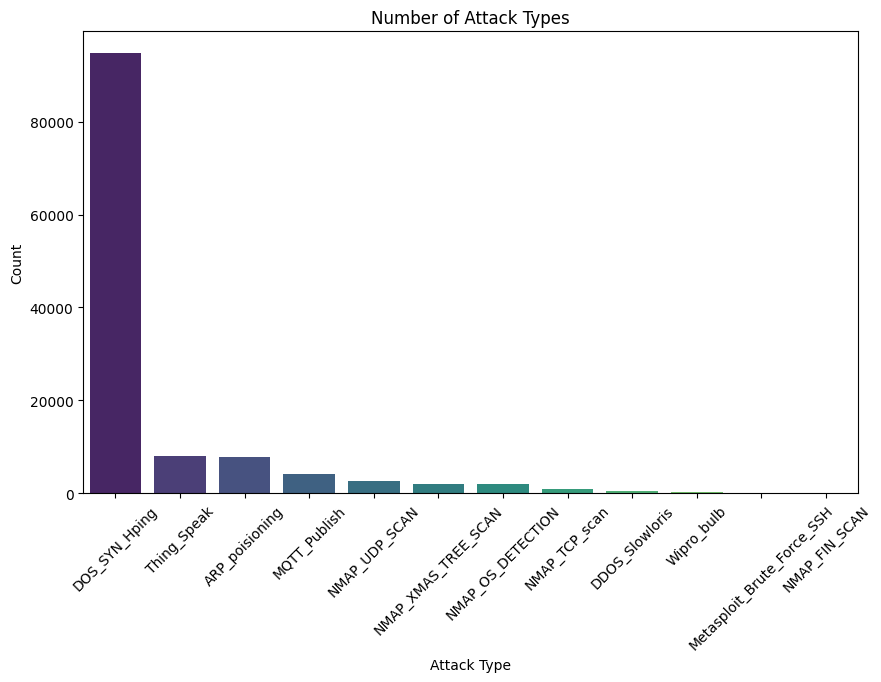

In [10]:
#barchart Number of attack types
attack_type_counts = df['Attack_type'].value_counts()

plt.figure(figsize=(10, 6))
sns.barplot(x=attack_type_counts.index, y=attack_type_counts.values, palette='viridis')
plt.title('Number of Attack Types')
plt.xlabel('Attack Type')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

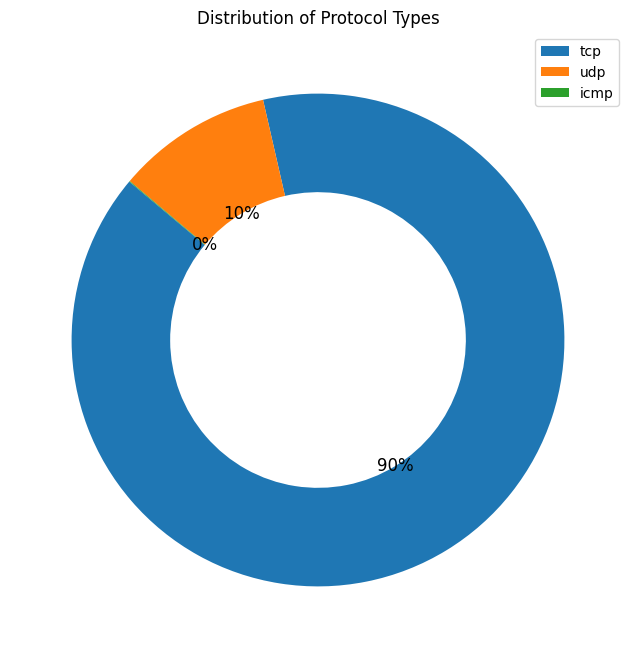

In [13]:
protocol_counts = df['proto'].value_counts()
plt.figure(figsize=(8, 8))
plt.pie(protocol_counts, labels=None, autopct='%1.0f%%', startangle=140, textprops={'fontsize': 12}, wedgeprops={'width': 0.4})
plt.title('Distribution of Protocol Types')
plt.legend(protocol_counts.index, loc='best', fontsize=10)
plt.show()

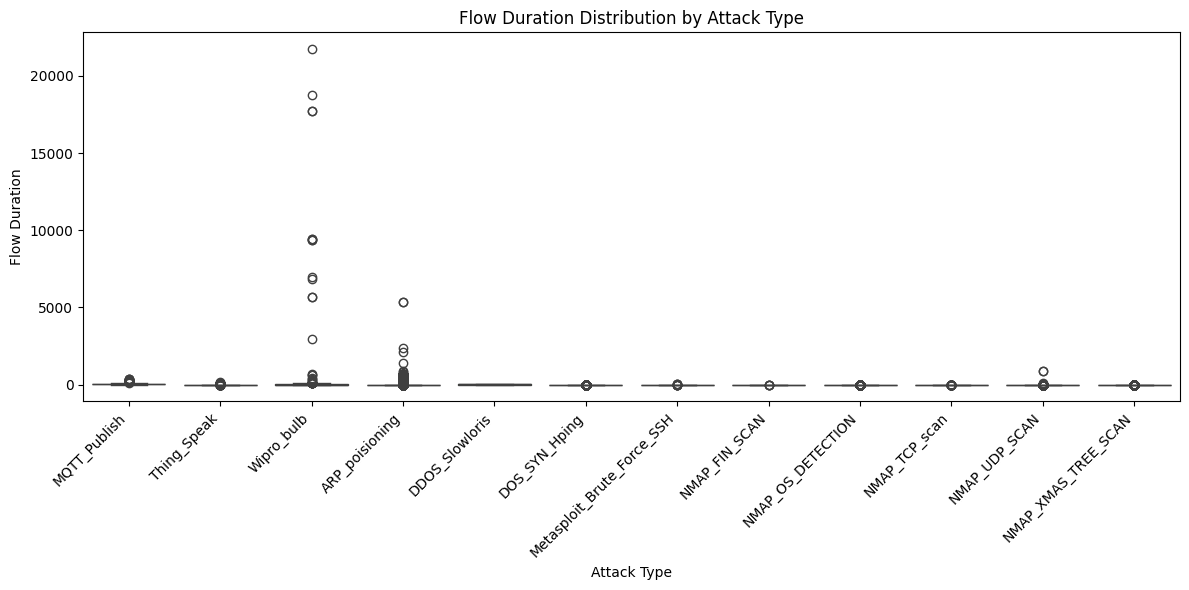

In [14]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='Attack_type', y='flow_duration', data=df, hue='Attack_type', legend=False)
plt.title('Flow Duration Distribution by Attack Type')
plt.xlabel('Attack Type')
plt.ylabel('Flow Duration')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()